# Sequential Federated Learning for Speaker Verification

This notebook merges all datasets (except Open_Test), trains a central model, performs sequential federated learning, and evaluates before and after on unseen phrases.

## Import Required Libraries

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset, ConcatDataset
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import random
from collections import defaultdict
import warnings
import copy
import json
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print("Libraries imported successfully!")

Libraries imported successfully!


## Load and Merge Datasets

In [2]:
# Load all datasets EXCEPT Open_Test (for training/validation)
print("Loading datasets...\n")

# Training data
train_feats = np.load(r'E:\ThesisSpeakerIdentification\NEWdataset\Train\train_feats.npy')
train_meta = pd.read_parquet(r'E:\ThesisSpeakerIdentification\NEWdataset\Train\train_meta.parquet')
print(f"✓ Train: {train_feats.shape[0]} samples, {len(train_meta['client_id'].unique())} speakers")

# Validation - Closed (same speaker - unseen phrases)
closed_val_feats = np.load(r'E:\ThesisSpeakerIdentification\NEWdataset\Val\closed_val_feats.npy')
closed_val_meta = pd.read_parquet(r'E:\ThesisSpeakerIdentification\NEWdataset\Val\closed_val_meta.parquet')
print(f"✓ Val-Closed: {closed_val_feats.shape[0]} samples, {len(closed_val_meta['client_id'].unique())} speakers")

# Validation - Open (unseen speakers)
open_val_feats = np.load(r'E:\ThesisSpeakerIdentification\NEWdataset\Val\open_val_feats.npy')
open_val_meta = pd.read_parquet(r'E:\ThesisSpeakerIdentification\NEWdataset\Val\open_val_meta.parquet')
print(f"✓ Val-Open: {open_val_feats.shape[0]} samples, {len(open_val_meta['client_id'].unique())} speakers")

# Test - KCT (same speaker - unseen phrases)
kct_feats = np.load(r'E:\ThesisSpeakerIdentification\NEWdataset\Test\kct_feats.npy')
kct_meta = pd.read_parquet(r'E:\ThesisSpeakerIdentification\NEWdataset\Test\kct_meta.parquet')
print(f"✓ Test-KCT: {kct_feats.shape[0]} samples, {len(kct_meta['client_id'].unique())} speakers")

# Test - Open (unseen speakers - for final evaluation)
open_test_feats = np.load(r'E:\ThesisSpeakerIdentification\NEWdataset\Test\open_test_feats.npy')
open_test_meta = pd.read_parquet(r'E:\ThesisSpeakerIdentification\NEWdataset\Test\open_test_meta.parquet')
print(f"✓ Test-Open: {open_test_feats.shape[0]} samples, {len(open_test_meta['client_id'].unique())} speakers")

print(f"\nFeature dimension: {train_feats.shape[1]}")

# Merge all datasets EXCEPT Open_Test for speaker splitting
print("\n" + "="*80)
print("MERGING DATASETS FOR SPEAKER SPLITTING")
print("="*80)

# Merge Train + Val-Closed + Val-Open + Test-KCT
all_feats = np.concatenate([train_feats, closed_val_feats, open_val_feats, kct_feats], axis=0)
all_meta = pd.concat([train_meta, closed_val_meta, open_val_meta, kct_meta], ignore_index=True)

print(f"Total merged data: {len(all_feats)} samples")
print(f"Total speakers: {len(all_meta['client_id'].unique())} speakers")

# Split speakers: 40% central, 20% each for 3 clients
all_speakers = list(set(all_meta['client_id'].unique()))
np.random.shuffle(all_speakers)
total_speakers = len(all_speakers)

central_split = int(total_speakers * 0.4)
client1_split = int(total_speakers * 0.6)
client2_split = int(total_speakers * 0.8)

central_train_speakers = all_speakers[:central_split]
client1_speakers = all_speakers[central_split:client1_split]
client2_speakers = all_speakers[client1_split:client2_split]
client3_speakers = all_speakers[client2_split:]

print(f"\nSpeaker split:")
print(f"  Central model: {len(central_train_speakers)} speakers (40%)")
print(f"  Client 1: {len(client1_speakers)} speakers (20%)")
print(f"  Client 2: {len(client2_speakers)} speakers (20%)")
print(f"  Client 3: {len(client3_speakers)} speakers (20%)")

# Verify no overlap
central_speakers_set = set(central_train_speakers)
client1_speakers_set = set(client1_speakers)
client2_speakers_set = set(client2_speakers)
client3_speakers_set = set(client3_speakers)

overlap_c1_c2 = central_speakers_set & client1_speakers_set
overlap_c1_c3 = central_speakers_set & client2_speakers_set
overlap_c1_c4 = central_speakers_set & client3_speakers_set
overlap_c2_c3 = client1_speakers_set & client2_speakers_set
overlap_c2_c4 = client1_speakers_set & client3_speakers_set
overlap_c3_c4 = client2_speakers_set & client3_speakers_set

print(f"\n🔍 Speaker overlap verification:")
print(f"  Central ∩ Client1: {len(overlap_c1_c2)} speakers ✓" if len(overlap_c1_c2) == 0 else f"  Central ∩ Client1: {len(overlap_c1_c2)} speakers ✗")
print(f"  Central ∩ Client2: {len(overlap_c1_c3)} speakers ✓" if len(overlap_c1_c3) == 0 else f"  Central ∩ Client2: {len(overlap_c1_c3)} speakers ✗")
print(f"  Central ∩ Client3: {len(overlap_c1_c4)} speakers ✓" if len(overlap_c1_c4) == 0 else f"  Central ∩ Client3: {len(overlap_c1_c4)} speakers ✗")
print(f"  Client1 ∩ Client2: {len(overlap_c2_c3)} speakers ✓" if len(overlap_c2_c3) == 0 else f"  Client1 ∩ Client2: {len(overlap_c2_c3)} speakers ✗")
print(f"  Client1 ∩ Client3: {len(overlap_c2_c4)} speakers ✓" if len(overlap_c2_c4) == 0 else f"  Client1 ∩ Client3: {len(overlap_c2_c4)} speakers ✗")
print(f"  Client2 ∩ Client3: {len(overlap_c3_c4)} speakers ✓" if len(overlap_c3_c4) == 0 else f"  Client2 ∩ Client3: {len(overlap_c3_c4)} speakers ✗")

print("\n" + "="*80)
print("SPLITTING DATA INTO TRAIN/VAL FOR EACH SPEAKER")
print("="*80)

# For each speaker, split their samples: 80% train, 20% validation
central_train_feats_list = []
central_train_meta_list = []
central_val_feats_list = []
central_val_meta_list = []

for speaker in central_train_speakers:
    speaker_mask = all_meta['client_id'] == speaker
    speaker_feats = all_feats[speaker_mask]
    speaker_meta = all_meta[speaker_mask].reset_index(drop=True)
    
    n_samples = len(speaker_feats)
    split_idx = int(n_samples * 0.8)
    
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    train_indices = indices[:split_idx]
    val_indices = indices[split_idx:]
    
    central_train_feats_list.append(speaker_feats[train_indices])
    central_train_meta_list.append(speaker_meta.iloc[train_indices])
    
    if len(val_indices) > 0:
        central_val_feats_list.append(speaker_feats[val_indices])
        central_val_meta_list.append(speaker_meta.iloc[val_indices])

central_train_feats_final = np.concatenate(central_train_feats_list, axis=0)
central_train_meta_final = pd.concat(central_train_meta_list, ignore_index=True)
central_val_feats = np.concatenate(central_val_feats_list, axis=0)
central_val_meta = pd.concat(central_val_meta_list, ignore_index=True)

print(f"Central model:")
print(f"  Train: {len(central_train_feats_final)} samples from {len(central_train_speakers)} speakers")
print(f"  Validation: {len(central_val_feats)} samples from {len(central_train_speakers)} speakers (unseen phrases)")

# Split client 1 data (80% train, 20% val)
client1_train_feats_list = []
client1_train_meta_list = []
client1_val_feats_list = []
client1_val_meta_list = []

for speaker in client1_speakers:
    speaker_mask = all_meta['client_id'] == speaker
    speaker_feats = all_feats[speaker_mask]
    speaker_meta = all_meta[speaker_mask].reset_index(drop=True)
    
    n_samples = len(speaker_feats)
    split_idx = int(n_samples * 0.8)
    
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    train_indices = indices[:split_idx]
    val_indices = indices[split_idx:]
    
    client1_train_feats_list.append(speaker_feats[train_indices])
    client1_train_meta_list.append(speaker_meta.iloc[train_indices])
    
    if len(val_indices) > 0:
        client1_val_feats_list.append(speaker_feats[val_indices])
        client1_val_meta_list.append(speaker_meta.iloc[val_indices])

client1_train_feats = np.concatenate(client1_train_feats_list, axis=0)
client1_train_meta = pd.concat(client1_train_meta_list, ignore_index=True)
client1_val_feats = np.concatenate(client1_val_feats_list, axis=0)
client1_val_meta = pd.concat(client1_val_meta_list, ignore_index=True)

print(f"\nClient 1:")
print(f"  Train: {len(client1_train_feats)} samples from {len(client1_speakers)} speakers")
print(f"  Validation: {len(client1_val_feats)} samples from {len(client1_speakers)} speakers (unseen phrases)")

# Split client 2 data (80% train, 20% val)
client2_train_feats_list = []
client2_train_meta_list = []
client2_val_feats_list = []
client2_val_meta_list = []

for speaker in client2_speakers:
    speaker_mask = all_meta['client_id'] == speaker
    speaker_feats = all_feats[speaker_mask]
    speaker_meta = all_meta[speaker_mask].reset_index(drop=True)
    
    n_samples = len(speaker_feats)
    split_idx = int(n_samples * 0.8)
    
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    train_indices = indices[:split_idx]
    val_indices = indices[split_idx:]
    
    client2_train_feats_list.append(speaker_feats[train_indices])
    client2_train_meta_list.append(speaker_meta.iloc[train_indices])
    
    if len(val_indices) > 0:
        client2_val_feats_list.append(speaker_feats[val_indices])
        client2_val_meta_list.append(speaker_meta.iloc[val_indices])

client2_train_feats = np.concatenate(client2_train_feats_list, axis=0)
client2_train_meta = pd.concat(client2_train_meta_list, ignore_index=True)
client2_val_feats = np.concatenate(client2_val_feats_list, axis=0)
client2_val_meta = pd.concat(client2_val_meta_list, ignore_index=True)

print(f"\nClient 2:")
print(f"  Train: {len(client2_train_feats)} samples from {len(client2_speakers)} speakers")
print(f"  Validation: {len(client2_val_feats)} samples from {len(client2_speakers)} speakers (unseen phrases)")

# Split client 3 data (80% train, 20% val)
client3_train_feats_list = []
client3_train_meta_list = []
client3_val_feats_list = []
client3_val_meta_list = []

for speaker in client3_speakers:
    speaker_mask = all_meta['client_id'] == speaker
    speaker_feats = all_feats[speaker_mask]
    speaker_meta = all_meta[speaker_mask].reset_index(drop=True)
    
    n_samples = len(speaker_feats)
    split_idx = int(n_samples * 0.8)
    
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    
    train_indices = indices[:split_idx]
    val_indices = indices[split_idx:]
    
    client3_train_feats_list.append(speaker_feats[train_indices])
    client3_train_meta_list.append(speaker_meta.iloc[train_indices])
    
    if len(val_indices) > 0:
        client3_val_feats_list.append(speaker_feats[val_indices])
        client3_val_meta_list.append(speaker_meta.iloc[val_indices])

client3_train_feats = np.concatenate(client3_train_feats_list, axis=0)
client3_train_meta = pd.concat(client3_train_meta_list, ignore_index=True)
client3_val_feats = np.concatenate(client3_val_feats_list, axis=0)
client3_val_meta = pd.concat(client3_val_meta_list, ignore_index=True)

print(f"\nClient 3:")
print(f"  Train: {len(client3_train_feats)} samples from {len(client3_speakers)} speakers")
print(f"  Validation: {len(client3_val_feats)} samples from {len(client3_speakers)} speakers (unseen phrases)")

# Create separate validation sets for fair comparison
print("\n" + "="*80)
print("CREATING SEPARATE VALIDATION SETS FOR FAIR COMPARISON")
print("="*80)

# Central validation: only central speakers
central_only_val_feats = central_val_feats
central_only_val_meta = central_val_meta

# Clients validation: combine all 3 clients' validation data
clients_val_feats = np.concatenate([client1_val_feats, client2_val_feats, client3_val_feats], axis=0)
clients_val_meta = pd.concat([client1_val_meta, client2_val_meta, client3_val_meta], ignore_index=True)

# All validation: combine central and clients
all_val_feats = np.concatenate([central_val_feats, clients_val_feats], axis=0)
all_val_meta = pd.concat([central_val_meta, clients_val_meta], ignore_index=True)

print(f"Central validation: {len(central_only_val_feats)} samples from {len(central_val_meta['client_id'].unique())} speakers")
print(f"Clients validation: {len(clients_val_feats)} samples from {len(clients_val_meta['client_id'].unique())} speakers")
print(f"All validation: {len(all_val_feats)} samples from {len(all_val_meta['client_id'].unique())} speakers")

print("\n✅ Data loading and splitting completed!")
print("="*80)

Loading datasets...

✓ Train: 38739 samples, 1609 speakers
✓ Val-Closed: 11728 samples, 1466 speakers
✓ Val-Open: 15290 samples, 639 speakers
✓ Test-KCT: 4808 samples, 711 speakers
✓ Test-Open: 35818 samples, 1491 speakers

Feature dimension: 692

MERGING DATASETS FOR SPEAKER SPLITTING
Total merged data: 70565 samples
Total speakers: 2248 speakers

Speaker split:
  Central model: 899 speakers (40%)
  Client 1: 449 speakers (20%)
  Client 2: 450 speakers (20%)
  Client 3: 450 speakers (20%)

🔍 Speaker overlap verification:
  Central ∩ Client1: 0 speakers ✓
  Central ∩ Client2: 0 speakers ✓
  Central ∩ Client3: 0 speakers ✓
  Client1 ∩ Client2: 0 speakers ✓
  Client1 ∩ Client3: 0 speakers ✓
  Client2 ∩ Client3: 0 speakers ✓

SPLITTING DATA INTO TRAIN/VAL FOR EACH SPEAKER
Central model:
  Train: 22019 samples from 899 speakers
  Validation: 5951 samples from 899 speakers (unseen phrases)

Client 1:
  Train: 11400 samples from 449 speakers
  Validation: 3090 samples from 449 speakers (unse

In [3]:
class SpeakerVerificationDataset(Dataset):
    """Dataset for speaker verification using pre-extracted features"""
    
    def __init__(self, features, metadata, mode='train'):
        """
        Args:
            features: numpy array of shape (N, feature_dim)
            metadata: pandas DataFrame with 'client_id' column
            mode: 'train' or 'test'
        """
        self.features = features
        self.metadata = metadata
        self.mode = mode
        
        # Group samples by speaker
        self.speaker_samples = defaultdict(list)
        for idx, row in metadata.iterrows():
            speaker_id = row['client_id']
            self.speaker_samples[speaker_id].append(idx)
        
        # Filter speakers with at least 2 samples (for positive pairs)
        self.speaker_samples = {k: v for k, v in self.speaker_samples.items() if len(v) >= 2}
        self.valid_speakers = list(self.speaker_samples.keys())
        
        print(f"Dataset mode: {mode}")
        print(f"Total samples: {len(features)}")
        print(f"Unique speakers: {len(self.valid_speakers)}")
        print(f"Feature dimension: {features.shape[1]}")
    
    def __len__(self):
        # Generate 4 pairs per speaker (2 positive + 2 negative)
        return len(self.valid_speakers) * 4
    
    def __getitem__(self, idx):
        speaker_idx = idx % len(self.valid_speakers)
        pair_type = (idx // len(self.valid_speakers)) % 4
        
        speaker_id = self.valid_speakers[speaker_idx]
        speaker_sample_indices = self.speaker_samples[speaker_id]
        
        if pair_type < 2:  # Positive pairs (same speaker)
            idx1 = random.choice(speaker_sample_indices)
            idx2 = random.choice(speaker_sample_indices)
            while idx2 == idx1 and len(speaker_sample_indices) > 1:
                idx2 = random.choice(speaker_sample_indices)
            label = 1.0  # Same speaker
        else:  # Negative pairs (different speakers)
            idx1 = random.choice(speaker_sample_indices)
            
            # Select different speaker
            different_speaker = random.choice(self.valid_speakers)
            while different_speaker == speaker_id:
                different_speaker = random.choice(self.valid_speakers)
            
            idx2 = random.choice(self.speaker_samples[different_speaker])
            label = 0.0  # Different speakers
        
        feat1 = torch.tensor(self.features[idx1], dtype=torch.float32)
        feat2 = torch.tensor(self.features[idx2], dtype=torch.float32)
        
        return feat1, feat2, torch.tensor(label, dtype=torch.float32)


class VerificationPairDataset(Dataset):
    """Dataset for evaluating verification on pre-defined pairs (closed/open test sets)"""
    
    def __init__(self, features, metadata, pair_type='same'):
        """
        Args:
            features: numpy array of shape (N, feature_dim)
            metadata: pandas DataFrame with 'client_id' column
            pair_type: 'same' for same-speaker pairs, 'different' for different-speaker pairs
        """
        self.features = features
        self.metadata = metadata
        self.pair_type = pair_type
        
        # Group samples by speaker
        self.speaker_samples = defaultdict(list)
        for idx, row in metadata.iterrows():
            speaker_id = row['client_id']
            self.speaker_samples[speaker_id].append(idx)
        
        self.valid_speakers = list(self.speaker_samples.keys())
        
        # Generate pairs
        self.pairs = []
        self.labels = []
        
        if pair_type == 'same':
            # Generate ALL same-speaker pairs
            for speaker_id, indices in self.speaker_samples.items():
                if len(indices) >= 2:
                    # Create all possible pairs
                    for i in range(len(indices)):
                        for j in range(i+1, len(indices)):
                            self.pairs.append((indices[i], indices[j]))
                            self.labels.append(1.0)
        else:
            # Generate different-speaker pairs
            # Calculate number of same-speaker pairs for this dataset to match
            num_same_pairs = sum(len(indices) * (len(indices) - 1) // 2 
                               for indices in self.speaker_samples.values() if len(indices) >= 2)
            
            # Generate equal number of different-speaker pairs
            num_diff_pairs = num_same_pairs
            
            print(f"Generating {num_diff_pairs:,} different-speaker pairs to match same-speaker pairs...")
            
            for _ in range(num_diff_pairs):
                speaker1, speaker2 = random.sample(self.valid_speakers, 2)
                idx1 = random.choice(self.speaker_samples[speaker1])
                idx2 = random.choice(self.speaker_samples[speaker2])
                self.pairs.append((idx1, idx2))
                self.labels.append(0.0)
        
        # Count positive and negative pairs properly
        num_positive = int(sum(self.labels))
        num_negative = len(self.labels) - num_positive
        
        print(f"\nVerification Pair Dataset ({pair_type} speakers)")
        print(f"Total pairs: {len(self.pairs)}")
        print(f"Positive pairs: {num_positive}")
        print(f"Negative pairs: {num_negative}")
    
    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, idx):
        idx1, idx2 = self.pairs[idx]
        feat1 = torch.tensor(self.features[idx1], dtype=torch.float32)
        feat2 = torch.tensor(self.features[idx2], dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return feat1, feat2, label

In [4]:
# Create datasets
print("\n" + "="*80)
print("CREATING DATASETS AND LOADERS")
print("="*80)

# Central model training dataset
central_train_dataset = SpeakerVerificationDataset(central_train_feats_final, central_train_meta_final, mode='train')
print()

# Central model validation dataset (only central speakers)
central_only_val_dataset = SpeakerVerificationDataset(central_only_val_feats, central_only_val_meta, mode='val')
print()

# Clients validation dataset (only client speakers)
clients_val_dataset = SpeakerVerificationDataset(clients_val_feats, clients_val_meta, mode='val')
print()

# Client datasets for federated learning
client1_dataset = SpeakerVerificationDataset(client1_train_feats, client1_train_meta, mode='train')
print()

client2_dataset = SpeakerVerificationDataset(client2_train_feats, client2_train_meta, mode='train')
print()

client3_dataset = SpeakerVerificationDataset(client3_train_feats, client3_train_meta, mode='train')
print()

# Create data loaders
num_workers = 0  # Use 0 for Windows compatibility
batch_size = 32

central_train_loader = DataLoader(
    central_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

central_val_loader = DataLoader(
    central_only_val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

clients_val_loader = DataLoader(
    clients_val_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print("="*80)
print("DATA LOADERS CREATED")
print("="*80)
print(f"Central training loader: {len(central_train_loader)} batches")
print(f"Central validation loader: {len(central_val_loader)} batches (central speakers only)")
print(f"Clients validation loader: {len(clients_val_loader)} batches (client speakers only)")
print("="*80)


CREATING DATASETS AND LOADERS
Dataset mode: train
Total samples: 22019
Unique speakers: 899
Feature dimension: 692

Dataset mode: val
Total samples: 5951
Unique speakers: 899
Feature dimension: 692

Dataset mode: val
Total samples: 9068
Unique speakers: 1349
Feature dimension: 692

Dataset mode: train
Total samples: 11400
Unique speakers: 449
Feature dimension: 692

Dataset mode: train
Total samples: 10845
Unique speakers: 450
Feature dimension: 692

Dataset mode: train
Total samples: 11282
Unique speakers: 450
Feature dimension: 692

DATA LOADERS CREATED
Central training loader: 113 batches
Central validation loader: 29 batches (central speakers only)
Clients validation loader: 43 batches (client speakers only)


In [5]:
# Create test dataset from Open_Test (unseen speakers)
print("\n" + "="*80)
print("CREATING TEST DATASET (OPEN_TEST - UNSEEN SPEAKERS)")
print("="*80)

test_same = VerificationPairDataset(open_test_feats, open_test_meta, pair_type='same')
test_diff = VerificationPairDataset(open_test_feats, open_test_meta, pair_type='different')
test_dataset = ConcatDataset([test_same, test_diff])

test_loader = DataLoader(
    test_dataset,
    batch_size=128,  # Increased batch size for faster evaluation
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True
)

print(f"\n✅ Test loader created: {len(test_loader)} batches")
print(f"Total test pairs: {len(test_dataset)}")
print("="*80)


CREATING TEST DATASET (OPEN_TEST - UNSEEN SPEAKERS)

Verification Pair Dataset (same speakers)
Total pairs: 448381
Positive pairs: 448381
Negative pairs: 0
Generating 448,381 different-speaker pairs to match same-speaker pairs...

Verification Pair Dataset (different speakers)
Total pairs: 448381
Positive pairs: 0
Negative pairs: 448381

✅ Test loader created: 7006 batches
Total test pairs: 896762


## Train Central Model

In [6]:
class SpeakerVerificationModel(nn.Module):
    """Deep Neural Network for Speaker Verification - Optimized for >95% F1"""
    
    def __init__(self, input_dim=692, hidden_dims=[512, 256], embedding_dim=128, dropout=0.4):
        super(SpeakerVerificationModel, self).__init__()
        
        self.input_dim = input_dim
        self.embedding_dim = embedding_dim
        
        # Speaker embedding network - Simplified but wider embeddings
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout * (0.75 ** i))  # Progressive dropout reduction
            ])
            prev_dim = hidden_dim
        
        # Larger embedding dimension for better speaker representation
        layers.append(nn.Linear(prev_dim, embedding_dim))
        
        self.embedding_net = nn.Sequential(*layers)
        
        # Similarity computation network - Deeper for better discrimination
        # Features: concat(emb1, emb2) + abs_diff + element_product + cosine = 4 * embedding_dim + 1
        similarity_input_dim = embedding_dim * 4 + 1  # Added cosine similarity
        self.similarity_net = nn.Sequential(
            nn.Linear(similarity_input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.5),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.3),
            
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x1, x2):
        # Get embeddings for both inputs
        emb1 = self.embedding_net(x1)
        emb2 = self.embedding_net(x2)
        
        # Normalize embeddings (L2 normalization)
        emb1_norm = F.normalize(emb1, p=2, dim=1)
        emb2_norm = F.normalize(emb2, p=2, dim=1)
        
        # Compute multiple similarity features
        concat_emb = torch.cat([emb1_norm, emb2_norm], dim=1)
        abs_diff = torch.abs(emb1_norm - emb2_norm)
        element_product = emb1_norm * emb2_norm
        
        # Cosine similarity as additional feature
        cosine_sim = (emb1_norm * emb2_norm).sum(dim=1, keepdim=True)
        
        # Combine all similarity features
        similarity_input = torch.cat([concat_emb, abs_diff, element_product, cosine_sim], dim=1)
        
        # Compute final similarity score
        similarity = self.similarity_net(similarity_input)
        
        return similarity.squeeze()
    
    def get_embedding(self, x):
        """Get speaker embedding for a single input"""
        with torch.no_grad():
            emb = self.embedding_net(x)
            return F.normalize(emb, p=2, dim=1)


class FocalLoss(nn.Module):
    """Focal Loss for handling class imbalance - Tuned for harder examples"""
    
    def __init__(self, alpha=1, gamma=3):  # Increased gamma for harder focus
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        
    def forward(self, inputs, targets):
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return focal_loss.mean()


def train_model(model, train_loader, val_loader, num_epochs=1000, learning_rate=0.0005, device='cpu', patience=150):
    """Train the speaker verification model with improved optimization"""
    
    criterion = FocalLoss(alpha=1, gamma=3)
    
    # Use AdamW with better weight decay and parameters optimized for convergence
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=5e-4, betas=(0.9, 0.999))
    
    # Cosine annealing with warm restarts for better convergence
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=50, T_mult=2, eta_min=1e-6)
    
    train_losses = []
    val_losses = []
    val_accuracies = []
    val_f1s = []
    
    best_val_f1 = 0.0
    patience_counter = 0
    
    model.to(device)
    
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        
        for x1, x2, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', disable=True):
            x1, x2, labels = x1.to(device), x2.to(device), labels.to(device)
            
            # Simple data augmentation: add small Gaussian noise to prevent overfitting
            if np.random.rand() > 0.5:
                x1 = x1 + torch.randn_like(x1) * 0.01
                x2 = x2 + torch.randn_like(x2) * 0.01
            
            optimizer.zero_grad()
            outputs = model(x1, x2)
            loss = criterion(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            epoch_train_loss += loss.item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        # Validation phase (skip if no val_loader)
        if val_loader is not None:
            model.eval()
            epoch_val_loss = 0.0
            all_predictions = []
            all_labels = []
            
            with torch.no_grad():
                for x1, x2, labels in val_loader:
                    x1, x2, labels = x1.to(device), x2.to(device), labels.to(device)
                    
                    outputs = model(x1, x2)
                    loss = criterion(outputs, labels)
                    
                    epoch_val_loss += loss.item()
                    
                    predictions = (outputs > 0.5).float()
                    all_predictions.extend(predictions.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
            
            avg_val_loss = epoch_val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            
            val_accuracy = accuracy_score(all_labels, all_predictions)
            precision, recall, val_f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='binary')
            
            val_accuracies.append(val_accuracy)
            val_f1s.append(val_f1)
            
            scheduler.step()
            
            # Print every 10 epochs
            if (epoch + 1) % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f'Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, '
                      f'Val Acc: {val_accuracy:.4f}, Val F1: {val_f1:.4f}, LR: {current_lr:.6f}')
            
            # Save best model based on F1-score
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                patience_counter = 0
                torch.save(model.state_dict(), 'best_central_model.pth')
                if (epoch + 1) % 5 == 0:
                    print(f'✓ New best F1: {best_val_f1:.4f}')
            else:
                patience_counter += 1
            
            # Early stopping
            if patience_counter >= patience:
                print(f'\n🛑 Early stopping triggered after {epoch+1} epochs')
                print(f'Best validation F1: {best_val_f1:.4f}')
                break
        else:
            # No validation - just track training loss
            val_losses.append(avg_train_loss)  # Use train loss as proxy
            val_accuracies.append(0.0)
            val_f1s.append(0.0)
            
            scheduler.step()
            
            # Print every 10 epochs
            if (epoch + 1) % 10 == 0:
                current_lr = optimizer.param_groups[0]['lr']
                print(f'Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, LR: {current_lr:.6f}')
    
    return {
        'train_loss': train_losses,
        'val_loss': val_losses,
        'val_accuracy': val_accuracies,
        'val_f1': val_f1s
    }

In [7]:
# Train central model
print("="*80)
print("TRAINING CENTRAL MODEL")
print("="*80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Initialize model
central_model = SpeakerVerificationModel(
    input_dim=692,
    hidden_dims=[512, 256],
    embedding_dim=128,
    dropout=0.4
)

print(f"Model parameters: {sum(p.numel() for p in central_model.parameters() if p.requires_grad):,}")

# Train the model - using central validation set
training_history = train_model(
    model=central_model,
    train_loader=central_train_loader,
    val_loader=central_val_loader,
    num_epochs=1000,
    learning_rate=0.0005,
    device=device,
    patience=150
)

print("\n✅ Central model training completed!")
print(f"Best validation F1: {max(training_history['val_f1']):.4f}")

# Load best model
central_model.load_state_dict(torch.load('best_central_model.pth'))

# Save central model
torch.save({
    'model_state_dict': central_model.state_dict(),
    'training_history': training_history,
    'best_f1': max(training_history['val_f1'])
}, 'central_model.pth')

print("💾 Central model saved to 'central_model.pth'")

TRAINING CENTRAL MODEL
Using device: cuda
Model parameters: 958,209
Epoch 10: Train Loss: 0.0548, Val Loss: 0.0459, Val Acc: 0.8454, Val F1: 0.8542, LR: 0.000452
✓ New best F1: 0.8542
✓ New best F1: 0.8743
Epoch 20: Train Loss: 0.0462, Val Loss: 0.0420, Val Acc: 0.8704, Val F1: 0.8786, LR: 0.000328
✓ New best F1: 0.8786
Epoch 30: Train Loss: 0.0415, Val Loss: 0.0388, Val Acc: 0.8918, Val F1: 0.8978, LR: 0.000173
Epoch 40: Train Loss: 0.0385, Val Loss: 0.0305, Val Acc: 0.9088, Val F1: 0.9124, LR: 0.000049
✓ New best F1: 0.9188
Epoch 50: Train Loss: 0.0397, Val Loss: 0.0308, Val Acc: 0.9132, Val F1: 0.9175, LR: 0.000500
Epoch 60: Train Loss: 0.0392, Val Loss: 0.0336, Val Acc: 0.9038, Val F1: 0.9078, LR: 0.000488
Epoch 70: Train Loss: 0.0399, Val Loss: 0.0335, Val Acc: 0.8971, Val F1: 0.9036, LR: 0.000452
Epoch 80: Train Loss: 0.0341, Val Loss: 0.0277, Val Acc: 0.9174, Val F1: 0.9195, LR: 0.000397
✓ New best F1: 0.9195
Epoch 90: Train Loss: 0.0339, Val Loss: 0.0249, Val Acc: 0.9283, Val F

## Perform Sequential Federated Learning

In [8]:
def sequential_federated_training(global_model, client_datasets, val_loader, num_cycles=5, epochs_per_client=3, learning_rate=2e-5, device='cpu'):
    """Sequential Federated Fine-Tuning with 3 Fixed Clients"""
    
    criterion = FocalLoss(alpha=1, gamma=3)
    
    # Create data loaders for each client
    federated_loaders = []
    num_clients = len(client_datasets)
    
    for client_idx, client_dataset in enumerate(client_datasets):
        loader = DataLoader(client_dataset, batch_size=32, shuffle=True, num_workers=0)
        federated_loaders.append(loader)
        print(f"Client {client_idx + 1}: {len(client_dataset.valid_speakers)} speakers, {len(client_dataset)} pairs")
    
    # Training history
    training_history = {
        'cycle': [],
        'client': [],
        'val_accuracy': [],
        'val_f1': [],
        'val_loss': []
    }
    
    best_val_f1 = 0.0
    global_model.to(device)
    
    for cycle in range(num_cycles):
        print(f"\n{'='*80}")
        print(f"CYCLE {cycle + 1}/{num_cycles}")
        print(f"{'='*80}")
        
        for client_idx, client_loader in enumerate(federated_loaders):
            print(f"--- Training on Client {client_idx + 1}/{len(federated_loaders)} ---")
            
            optimizer = optim.AdamW(global_model.parameters(), lr=learning_rate, weight_decay=1e-5, betas=(0.9, 0.999))
            
            global_model.train()
            for epoch in range(epochs_per_client):
                epoch_loss = 0.0
                
                for x1, x2, labels in client_loader:
                    x1, x2, labels = x1.to(device), x2.to(device), labels.to(device)
                    
                    if np.random.rand() > 0.7:
                        x1 = x1 + torch.randn_like(x1) * 0.005
                        x2 = x2 + torch.randn_like(x2) * 0.005
                    
                    optimizer.zero_grad()
                    outputs = global_model(x1, x2)
                    loss = criterion(outputs, labels)
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(global_model.parameters(), max_norm=0.5)
                    optimizer.step()
                    
                    epoch_loss += loss.item()
                
                print(f"  Epoch {epoch+1}/{epochs_per_client}: Loss {epoch_loss/len(client_loader):.4f}")
            
            # Validate after this client
            global_model.eval()
            val_loss = 0.0
            all_preds = []
            all_labels = []
            
            with torch.no_grad():
                for x1, x2, labels in val_loader:
                    x1, x2, labels = x1.to(device), x2.to(device), labels.to(device)
                    outputs = global_model(x1, x2)
                    loss = criterion(outputs, labels)
                    val_loss += loss.item()
                    
                    predictions = (outputs > 0.5).float()
                    all_preds.extend(predictions.cpu().numpy())
                    all_labels.extend(labels.cpu().numpy())
            
            avg_val_loss = val_loss / len(val_loader)
            val_acc = accuracy_score(all_labels, all_preds)
            _, _, val_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
            
            training_history['cycle'].append(cycle + 1)
            training_history['client'].append(client_idx + 1)
            training_history['val_accuracy'].append(val_acc)
            training_history['val_f1'].append(val_f1)
            training_history['val_loss'].append(avg_val_loss)
            
            print(f"  After Client {client_idx + 1}: Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}")
            
            if val_f1 > best_val_f1:
                best_val_f1 = val_f1
                torch.save(global_model.state_dict(), 'best_federated_model.pth')
                print(f"  ✓ New best F1: {best_val_f1:.4f}")
    
    print(f"\nSequential Fine-Tuning Completed! Best F1: {best_val_f1:.4f}")
    global_model.load_state_dict(torch.load('best_federated_model.pth'))
    
    return global_model, training_history


# Perform sequential federated learning
print("="*80)
print("SEQUENTIAL FEDERATED LEARNING (3 CLIENTS)")
print("="*80)

num_cycles = 100
epochs_per_client = 20
learning_rate = 2e-5

print(f"Number of clients: 3 (fixed)")
print(f"Number of cycles: {num_cycles}")
print(f"Epochs per client: {epochs_per_client}")
print(f"Learning rate: {learning_rate}")

# Start from the trained central model
federated_model = SpeakerVerificationModel(input_dim=692, hidden_dims=[512, 256], embedding_dim=128, dropout=0.4)
federated_model.load_state_dict(central_model.state_dict())

# Pass the 3 client datasets
client_datasets = [client1_dataset, client2_dataset, client3_dataset]

federated_model, federated_history = sequential_federated_training(
    global_model=federated_model,
    client_datasets=client_datasets,
    val_loader=clients_val_loader,  # Use clients validation set
    num_cycles=num_cycles,
    epochs_per_client=epochs_per_client,
    learning_rate=learning_rate,
    device=device
)

print("\n✅ Sequential federated learning completed!")
print(f"Central model F1: {max(training_history['val_f1']):.4f}")
print(f"Federated model F1: {max(federated_history['val_f1']):.4f}")
print(f"Improvement: {max(federated_history['val_f1']) - max(training_history['val_f1']):+.4f}")

# Save federated model
torch.save({
    'model_state_dict': federated_model.state_dict(),
    'federated_history': federated_history,
    'central_f1': max(training_history['val_f1']),
    'federated_f1': max(federated_history['val_f1'])
}, 'federated_model.pth')

print("💾 Federated model saved to 'federated_model.pth'")

SEQUENTIAL FEDERATED LEARNING (3 CLIENTS)
Number of clients: 3 (fixed)
Number of cycles: 100
Epochs per client: 20
Learning rate: 2e-05
Client 1: 449 speakers, 1796 pairs
Client 2: 450 speakers, 1800 pairs
Client 3: 450 speakers, 1800 pairs

CYCLE 1/100
--- Training on Client 1/3 ---
  Epoch 1/20: Loss 0.0632
  Epoch 2/20: Loss 0.0609
  Epoch 3/20: Loss 0.0635
  Epoch 4/20: Loss 0.0534
  Epoch 5/20: Loss 0.0562
  Epoch 6/20: Loss 0.0565
  Epoch 7/20: Loss 0.0752
  Epoch 8/20: Loss 0.0621
  Epoch 9/20: Loss 0.0436
  Epoch 10/20: Loss 0.0496
  Epoch 11/20: Loss 0.0626
  Epoch 12/20: Loss 0.0507
  Epoch 13/20: Loss 0.0457
  Epoch 14/20: Loss 0.0650
  Epoch 15/20: Loss 0.0499
  Epoch 16/20: Loss 0.0419
  Epoch 17/20: Loss 0.0391
  Epoch 18/20: Loss 0.0483
  Epoch 19/20: Loss 0.0389
  Epoch 20/20: Loss 0.0577
  After Client 1: Val Loss: 0.0344, Val Acc: 0.9020, Val F1: 0.9030
  ✓ New best F1: 0.9030
--- Training on Client 2/3 ---
  Epoch 1/20: Loss 0.0448
  Epoch 2/20: Loss 0.0437
  Epoch 3

## Evaluate Model Before and After Federated Learning

In [9]:
def evaluate_model(model, test_loader, device='cpu', dataset_name='Test'):
    """Evaluate the model on test set"""
    
    model.eval()
    all_predictions = []
    all_labels = []
    all_scores = []
    
    with torch.no_grad():
        for x1, x2, labels in tqdm(test_loader, desc=f'Evaluating {dataset_name}', disable=True):
            x1, x2, labels = x1.to(device), x2.to(device), labels.to(device)
            
            outputs = model(x1, x2)
            
            all_scores.extend(outputs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            predictions = (outputs > 0.5).float()
            all_predictions.extend(predictions.cpu().numpy())
    
    # Calculate metrics
    accuracy = accuracy_score(all_labels, all_predictions)
    
    # Check if we have both classes for proper metric calculation
    unique_labels = np.unique(all_labels)
    
    if len(unique_labels) == 2:
        # Both classes present - use binary averaging
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='binary')
        try:
            auc = roc_auc_score(all_labels, all_scores)
        except:
            auc = float('nan')
    elif unique_labels[0] == 0:
        # Only negative class (different speakers) - evaluate as negative class
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='binary', pos_label=0)
        # For AUC with single class, we can't compute it
        auc = float('nan')
    else:
        # Only positive class (same speakers)
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='binary')
        auc = float('nan')
    
    print(f'\n{"="*80}')
    print(f'{dataset_name} Results:')
    print(f'{"="*80}')
    print(f'Accuracy:  {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall:    {recall:.4f}')
    print(f'F1-Score:  {f1:.4f}')
    if not np.isnan(auc):
        print(f'AUC-ROC:   {auc:.4f}')
    else:
        print(f'AUC-ROC:   N/A (single class dataset)')
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc if not np.isnan(auc) else 0.0,
        'predictions': all_predictions,
        'labels': all_labels,
        'scores': all_scores
    }


# Evaluate central model before federated learning
print("="*80)
print("EVALUATION BEFORE FEDERATED LEARNING")
print("="*80)

central_model.load_state_dict(torch.load('best_central_model.pth'))
central_results = evaluate_model(central_model, test_loader, device, dataset_name='Central Model (Before Federated)')

# Evaluate federated model after federated learning
print("\n" + "="*80)
print("EVALUATION AFTER FEDERATED LEARNING")
print("="*80)

federated_model.load_state_dict(torch.load('federated_model.pth')['model_state_dict'])
federated_results = evaluate_model(federated_model, test_loader, device, dataset_name='Federated Model (After Federated)')

print("\n" + "="*100)
print("COMPARISON SUMMARY")
print("="*100)
print(f"Central Model F1:    {central_results['f1']:.4f}")
print(f"Federated Model F1:  {federated_results['f1']:.4f}")
print(f"Improvement:         {federated_results['f1'] - central_results['f1']:+.4f}")
print(f"Central Accuracy:    {central_results['accuracy']:.4f}")
print(f"Federated Accuracy:  {federated_results['accuracy']:.4f}")
print(f"Improvement:         {federated_results['accuracy'] - central_results['accuracy']:+.4f}")
print("="*100)

EVALUATION BEFORE FEDERATED LEARNING

Central Model (Before Federated) Results:
Accuracy:  0.9060
Precision: 0.9281
Recall:    0.8801
F1-Score:  0.9035
AUC-ROC:   0.9688

EVALUATION AFTER FEDERATED LEARNING

Federated Model (After Federated) Results:
Accuracy:  0.9210
Precision: 0.9277
Recall:    0.9132
F1-Score:  0.9204
AUC-ROC:   0.9759

COMPARISON SUMMARY
Central Model F1:    0.9035
Federated Model F1:  0.9204
Improvement:         +0.0169
Central Accuracy:    0.9060
Federated Accuracy:  0.9210
Improvement:         +0.0150


## Calculate Equal Error Rate (EER)

EER is a standard metric in speaker verification that represents the point where False Acceptance Rate (FAR) equals False Rejection Rate (FRR). Lower EER indicates better performance.

In [11]:
from scipy.optimize import brentq
from scipy.interpolate import interp1d

def calculate_eer(labels, scores):
    """
    Calculate Equal Error Rate (EER) from labels and scores
    
    Args:
        labels: Ground truth binary labels (1 for same speaker, 0 for different)
        scores: Model prediction scores (higher means more similar)
    
    Returns:
        eer: Equal Error Rate (percentage)
        threshold: Threshold at which EER occurs
    """
    fpr, tpr, thresholds = roc_curve(labels, scores)
    frr = 1 - tpr  # False Rejection Rate = 1 - True Positive Rate
    far = fpr      # False Acceptance Rate = False Positive Rate
    
    # Find the threshold where FAR = FRR
    abs_diff = np.abs(far - frr)
    min_index = np.argmin(abs_diff)
    eer = (far[min_index] + frr[min_index]) / 2
    threshold = thresholds[min_index]
    
    # Alternative: Use interpolation for more precise EER
    try:
        eer_interp = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)
    except:
        eer_interp = eer
    
    return eer * 100, threshold  # Return as percentage


# Calculate EER for both models
print("="*80)
print("CALCULATING EQUAL ERROR RATE (EER)")
print("="*80)

central_eer, central_threshold = calculate_eer(central_results['labels'], central_results['scores'])
federated_eer, federated_threshold = calculate_eer(federated_results['labels'], federated_results['scores'])

print(f"\n📊 Equal Error Rate (EER) Results:")
print(f"{'='*80}")
print(f"Central Model:")
print(f"  EER: {central_eer:.2f}%")
print(f"  Optimal Threshold: {central_threshold:.4f}")
print(f"\nFederated Model:")
print(f"  EER: {federated_eer:.2f}%")
print(f"  Optimal Threshold: {federated_threshold:.4f}")
print(f"\n📈 Improvement:")
print(f"  EER Reduction: {central_eer - federated_eer:.2f}% (lower is better)")
print(f"  Relative Improvement: {((central_eer - federated_eer) / central_eer * 100):.2f}%")
print("="*80)

# Comprehensive results table
print("\n" + "="*100)
print("COMPREHENSIVE RESULTS TABLE (FOR PAPER)")
print("="*100)
print(f"{'Metric':<20} {'Central Model':<20} {'Federated Model':<20} {'Improvement':<20}")
print("="*100)
print(f"{'Accuracy (%)':<20} {central_results['accuracy']*100:<20.2f} {federated_results['accuracy']*100:<20.2f} {(federated_results['accuracy']-central_results['accuracy'])*100:<20.2f}")
print(f"{'Precision (%)':<20} {central_results['precision']*100:<20.2f} {federated_results['precision']*100:<20.2f} {(federated_results['precision']-central_results['precision'])*100:<20.2f}")
print(f"{'Recall (%)':<20} {central_results['recall']*100:<20.2f} {federated_results['recall']*100:<20.2f} {(federated_results['recall']-central_results['recall'])*100:<20.2f}")
print(f"{'F1-Score (%)':<20} {central_results['f1']*100:<20.2f} {federated_results['f1']*100:<20.2f} {(federated_results['f1']-central_results['f1'])*100:<20.2f}")
print(f"{'AUC-ROC':<20} {central_results['auc']:<20.4f} {federated_results['auc']:<20.4f} {federated_results['auc']-central_results['auc']:<20.4f}")
print(f"{'EER (%)':<20} {central_eer:<20.2f} {federated_eer:<20.2f} {central_eer-federated_eer:<20.2f}")
print("="*100)

# Update results summary with EER
results_summary['central_model']['eer'] = float(central_eer)
results_summary['central_model']['eer_threshold'] = float(central_threshold)
results_summary['federated_model']['eer'] = float(federated_eer)
results_summary['federated_model']['eer_threshold'] = float(federated_threshold)
results_summary['improvement']['eer_reduction'] = float(central_eer - federated_eer)

# Save updated results
with open('sequential_federated_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\n✅ EER calculated and results updated!")
print("📄 Updated results saved to 'sequential_federated_results.json'")

CALCULATING EQUAL ERROR RATE (EER)

📊 Equal Error Rate (EER) Results:
Central Model:
  EER: 9.27%
  Optimal Threshold: 0.4473

Federated Model:
  EER: 7.93%
  Optimal Threshold: 0.4853

📈 Improvement:
  EER Reduction: 1.34% (lower is better)
  Relative Improvement: 14.44%

COMPREHENSIVE RESULTS TABLE (FOR PAPER)
Metric               Central Model        Federated Model      Improvement         
Accuracy (%)         90.60                92.10                1.50                
Precision (%)        92.81                92.77                -0.04               
Recall (%)           88.01                91.32                3.31                
F1-Score (%)         90.35                92.04                1.69                
AUC-ROC              0.9688               0.9759               0.0071              
EER (%)              9.27                 7.93                 1.34                

✅ EER calculated and results updated!
📄 Updated results saved to 'sequential_federated_results.js

## Visualization and Results

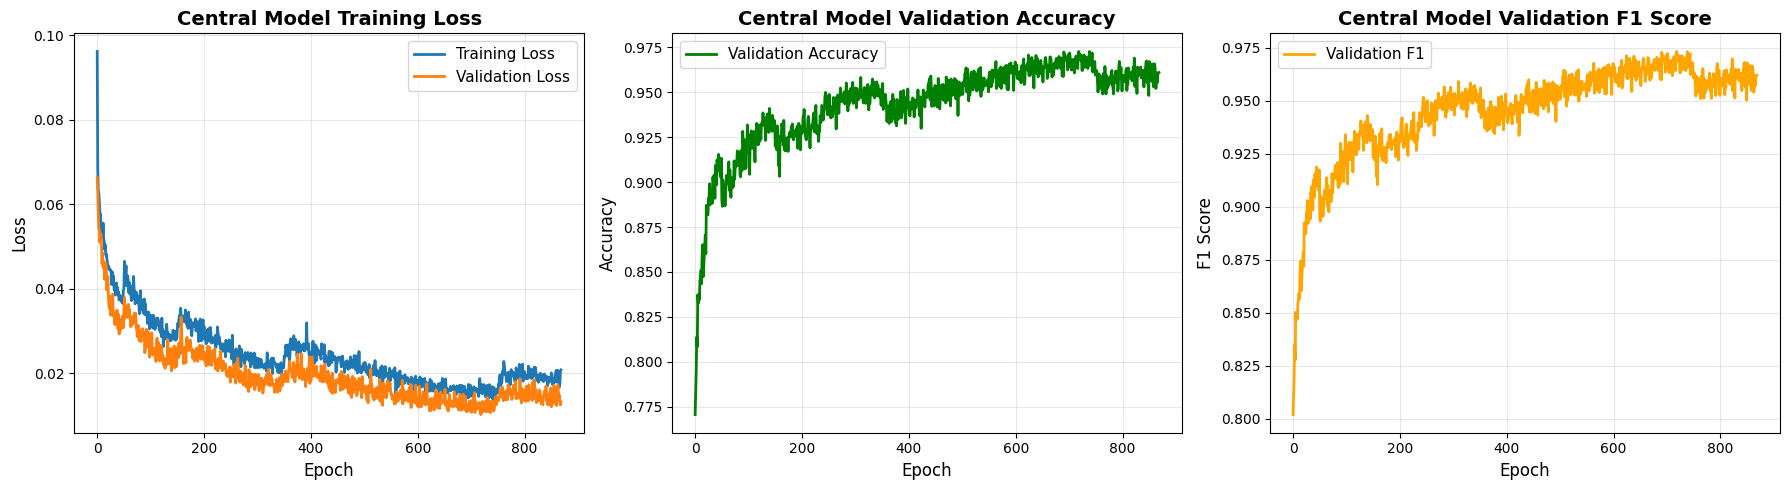

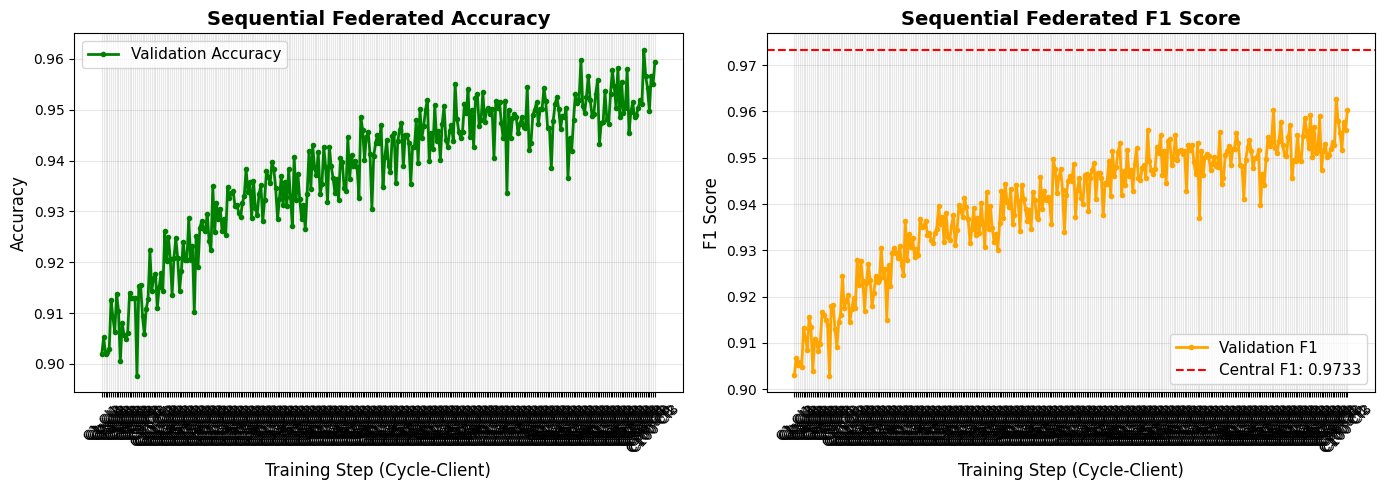

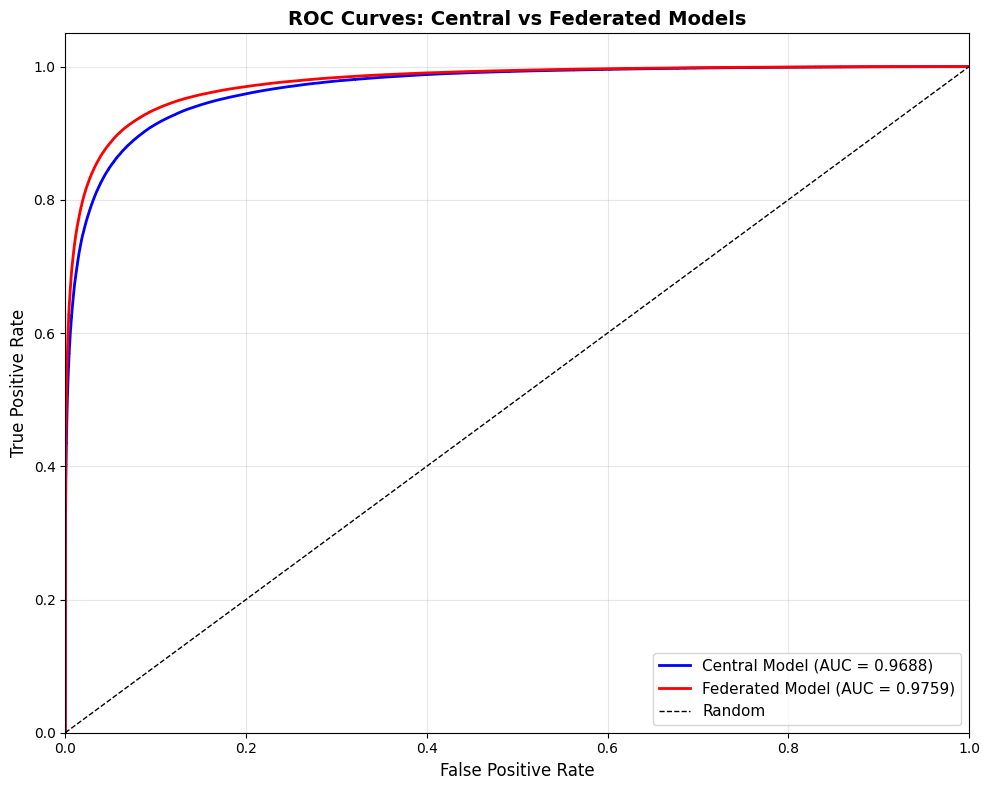

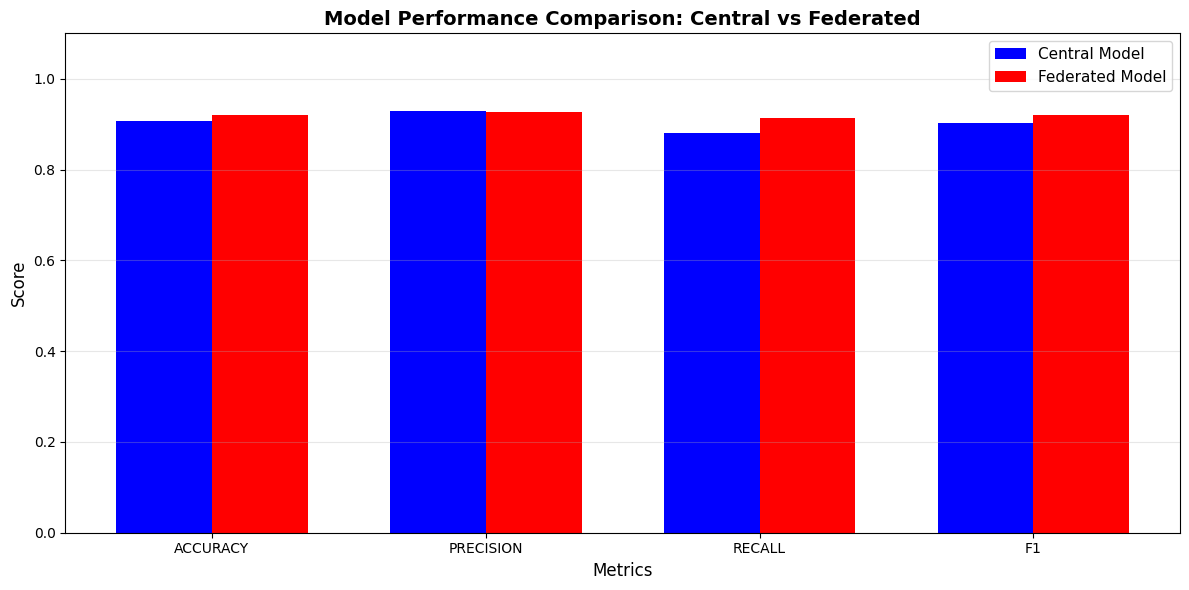

✅ Visualization and results saved!
📁 Files saved to 'sequential_federated_output/'
📄 Results summary saved to 'sequential_federated_results.json'

FINAL SUMMARY
Central Model Performance:
  F1: 0.9035, Accuracy: 0.9060
Federated Model Performance:
  F1: 0.9204, Accuracy: 0.9210
Improvement:
  F1: +0.0169
  Accuracy: +0.0150


In [10]:
# Create output directory
os.makedirs('sequential_federated_output', exist_ok=True)

# Plot training curves for central model
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(training_history['train_loss'], label='Training Loss', linewidth=2)
axes[0].plot(training_history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_title('Central Model Training Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(training_history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='green')
axes[1].set_title('Central Model Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(training_history['val_f1'], label='Validation F1', linewidth=2, color='orange')
axes[2].set_title('Central Model Validation F1 Score', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('F1 Score', fontsize=12)
axes[2].legend(fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sequential_federated_output/central_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot federated training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_axis = [f"C{c}-Cl{cl}" for c, cl in zip(federated_history['cycle'], federated_history['client'])]

axes[0].plot(x_axis, federated_history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='green', marker='o', markersize=3)
axes[0].set_title('Sequential Federated Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Training Step (Cycle-Client)', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(x_axis, federated_history['val_f1'], label='Validation F1', linewidth=2, color='orange', marker='o', markersize=3)
axes[1].axhline(y=max(training_history['val_f1']), color='red', linestyle='--', label=f'Central F1: {max(training_history["val_f1"]):.4f}')
axes[1].set_title('Sequential Federated F1 Score', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Training Step (Cycle-Client)', fontsize=12)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('sequential_federated_output/federated_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot ROC curves
plt.figure(figsize=(10, 8))

# Central model
if central_results['auc'] > 0:
    fpr, tpr, _ = roc_curve(central_results['labels'], central_results['scores'])
    plt.plot(fpr, tpr, label=f'Central Model (AUC = {central_results["auc"]:.4f})', linewidth=2, color='blue')

# Federated model
if federated_results['auc'] > 0:
    fpr, tpr, _ = roc_curve(federated_results['labels'], federated_results['scores'])
    plt.plot(fpr, tpr, label=f'Federated Model (AUC = {federated_results["auc"]:.4f})', linewidth=2, color='red')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves: Central vs Federated Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('sequential_federated_output/roc_curves_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot comparison bar chart
metrics = ['accuracy', 'precision', 'recall', 'f1']
models = ['Central', 'Federated']
values_central = [central_results[m] for m in metrics]
values_federated = [federated_results[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, values_central, width, label='Central Model', color='blue')
ax.bar(x + width/2, values_federated, width, label='Federated Model', color='red')

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison: Central vs Federated', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in metrics])
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim([0, 1.1])

plt.tight_layout()
plt.savefig('sequential_federated_output/models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Save results
results_summary = {
    'central_model': {
        'f1': central_results['f1'],
        'accuracy': central_results['accuracy'],
        'precision': central_results['precision'],
        'recall': central_results['recall'],
        'auc': central_results['auc']
    },
    'federated_model': {
        'f1': federated_results['f1'],
        'accuracy': federated_results['accuracy'],
        'precision': federated_results['precision'],
        'recall': federated_results['recall'],
        'auc': federated_results['auc']
    },
    'improvement': {
        'f1': federated_results['f1'] - central_results['f1'],
        'accuracy': federated_results['accuracy'] - central_results['accuracy']
    },
    'training_info': {
        'central_epochs': len(training_history['val_f1']),
        'federated_cycles': num_cycles,
        'federated_clients': 3,
        'epochs_per_client': epochs_per_client
    }
}

with open('sequential_federated_results.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("✅ Visualization and results saved!")
print("📁 Files saved to 'sequential_federated_output/'")
print("📄 Results summary saved to 'sequential_federated_results.json'")

print("\n" + "="*100)
print("FINAL SUMMARY")
print("="*100)
print(f"Central Model Performance:")
print(f"  F1: {central_results['f1']:.4f}, Accuracy: {central_results['accuracy']:.4f}")
print(f"Federated Model Performance:")
print(f"  F1: {federated_results['f1']:.4f}, Accuracy: {federated_results['accuracy']:.4f}")
print(f"Improvement:")
print(f"  F1: {federated_results['f1'] - central_results['f1']:+.4f}")
print(f"  Accuracy: {federated_results['accuracy'] - central_results['accuracy']:+.4f}")
print("="*100)